# Data Exploration
Exactly what the model sees — from raw parquet to the rolled windows fed into the quantum circuit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.color':       '#e5e5e5',
    'grid.linewidth':   0.7,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

---
## 1. Load all data files

In [2]:
price      = pd.read_parquet('./data/price_data.parquet.gzip')
price_train = pd.read_parquet('./data/price_data_train.parquet.gzip')
price_val   = pd.read_parquet('./data/price_data_val.parquet.gzip')
price_test  = pd.read_parquet('./data/price_data_test.parquet.gzip')

volume      = pd.read_parquet('./data/volume_data.parquet.gzip')
volume_train = pd.read_parquet('./data/volume_data_train.parquet.gzip')
volume_val   = pd.read_parquet('./data/volume_data_val.parquet.gzip')
volume_test  = pd.read_parquet('./data/volume_data_test.parquet.gzip')

print('price  :', price.shape,  '|', price.index[0].date(), '→', price.index[-1].date())
print('volume :', volume.shape, '|', volume.index[0].date(), '→', volume.index[-1].date())

price  : (3536, 15) | 2011-08-09 → 2025-08-29
volume : (3536, 15) | 2011-08-09 → 2025-08-29


---
## 2. What exactly is stored — dtypes, index, columns

In [3]:
print('=== price_data dtypes ===')
print(price.dtypes)
print()
print('Index type :', type(price.index).__name__)
print('Index freq :', price.index.freq)
print('Index dtype:', price.index.dtype)

=== price_data dtypes ===
Ticker
AAPL    float64
EFA     float64
GLD     float64
IWM     float64
JNJ     float64
JPM     float64
LQD     float64
MSFT    float64
QQQ     float64
SPY     float64
TLT     float64
USO     float64
XLF     float64
XLV     float64
XOM     float64
dtype: object

Index type : DatetimeIndex
Index freq : None
Index dtype: datetime64[ns]


In [4]:
price.head(10)

Ticker,AAPL,EFA,GLD,IWM,JNJ,JPM,LQD,MSFT,QQQ,SPY,TLT,USO,XLF,XLV,XOM
Date,,,,,,,,,,,,,,,
2011-08-09,0.057220,0.065192,0.008876,0.064519,0.017516,0.066445,0.008927,4.395426e-02,0.047104,0.045451,0.003028,0.003485,0.074460,0.035800,0.020448
2011-08-10,-0.027981,-0.061579,0.034795,-0.050187,-0.032682,-0.057385,0.008936,-5.545772e-02,-0.041781,-0.045183,0.029319,0.005047,-0.071996,-0.043116,-0.045123
2011-08-11,0.027152,0.046775,-0.022183,0.048747,0.052422,0.065320,-0.020737,4.009421e-02,0.043100,0.043906,-0.051766,0.046720,0.054283,0.044713,0.050868
2011-08-12,0.008765,0.011407,-0.004579,0.006181,-0.001262,-0.021489,0.011356,-3.579115e-03,0.008812,0.006711,0.019609,-0.002104,-0.007018,0.009846,0.005850
2011-08-15,0.016887,0.022985,0.010709,0.027836,0.019227,0.026654,0.001865,1.620257e-02,0.014639,0.020944,-0.010187,0.029357,0.031577,0.016612,0.031310
2011-08-16,-0.007671,-0.014702,0.012264,-0.018566,-0.003567,-0.023318,0.003632,1.940326e-07,-0.008498,-0.008576,0.016420,-0.011462,-0.019908,-0.000933,-0.010691
2011-08-17,-0.000105,0.005795,0.002871,0.000284,-0.001555,0.014876,0.002737,-3.952483e-03,-0.005954,0.000669,0.017357,0.005307,0.006168,0.000933,0.008940
2011-08-18,-0.038559,-0.049872,0.018743,-0.058596,-0.017266,-0.038466,0.001322,-2.323868e-02,-0.050331,-0.044076,0.020330,-0.069707,-0.049636,-0.033505,-0.044391
2011-08-19,-0.027754,-0.017192,0.012470,-0.017764,-0.000317,-0.024160,-0.001233,-2.545286e-02,-0.018222,-0.016465,0.008036,0.012531,-0.020400,-0.002575,-0.016201


In [5]:
price.tail(5)

Ticker,AAPL,EFA,GLD,IWM,JNJ,JPM,LQD,MSFT,QQQ,SPY,TLT,USO,XLF,XLV,XOM
Date,,,,,,,,,,,,,,,
2025-08-25,-0.002638,-0.013281,-0.002418,-0.010574,-0.004920,-0.004534,-0.002635,-0.005873,-0.002889,-0.004411,-0.002876,0.014762,-0.005804,-0.014360,0.004125
2025-08-26,0.009420,-0.001087,0.007236,0.008229,-0.003507,0.012368,0.000728,-0.004412,0.004007,0.004178,-0.000576,-0.022698,0.007669,0.006222,-0.002240
2025-08-27,0.005133,-0.002397,0.002017,0.007061,0.001698,0.002375,0.000364,0.009318,0.001536,0.002276,-0.001153,0.008472,0.002047,-0.000584,0.011238
2025-08-28,0.008941,0.003702,0.007392,0.001186,-0.007608,0.005963,0.001544,0.005707,0.006240,0.003535,0.006557,0.007471,0.001301,-0.003950,0.005307
2025-08-29,-0.001808,-0.005886,0.009604,-0.004455,0.009755,0.001162,-0.003636,-0.005805,-0.011643,-0.005982,-0.007134,-0.005331,0.002596,0.007303,0.008259


---
## 3. Train / Val / Test splits

In [6]:
splits = {
    'train': price_train,
    'val':   price_val,
    'test':  price_test,
}

for name, df in splits.items():
    pct = 100 * len(df) / len(price)
    print(f'{name:6s}: {len(df):5d} rows ({pct:.1f}%)  |  {df.index[0].date()} → {df.index[-1].date()}')

print(f'\ntotal:  {len(price):5d} rows')
print(f'gap check — train+val+test = {len(price_train)+len(price_val)+len(price_test)} rows')

train :  2121 rows (60.0%)  |  2011-08-09 → 2020-01-13
val   :   707 rows (20.0%)  |  2020-01-14 → 2022-11-01
test  :   708 rows (20.0%)  |  2022-11-02 → 2025-08-29

total:   3536 rows
gap check — train+val+test = 3536 rows


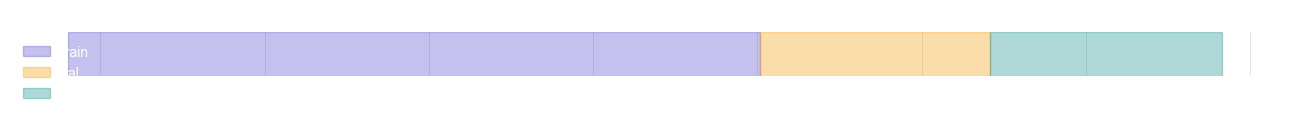

In [7]:
fig, ax = plt.subplots(figsize=(13, 1.4))
colours = {'train': '#5b4fcf', 'val': '#f59e0b', 'test': '#1a9090'}
for name, df in splits.items():
    ax.axvspan(df.index[0], df.index[-1], alpha=0.35, color=colours[name], label=name)
ax.set_yticks([])
ax.set_xlabel('Date')
ax.set_title('Train / Val / Test split', fontweight='bold', pad=8)
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

---
## 4. Missing data

In [8]:
nulls = price.isnull().sum()
zeros = (price == 0).sum()

missing = pd.DataFrame({'nulls': nulls, 'zeros (fillna(0) applied)': zeros})
print(missing.to_string())
print(f'\nAny NaN anywhere: {price.isnull().any().any()}')

        nulls  zeros (fillna(0) applied)
Ticker                                  
AAPL        0                          7
EFA         0                         25
GLD         0                         11
IWM         0                          6
JNJ         0                         18
JPM         0                         18
LQD         0                         33
MSFT        0                         25
QQQ         0                         12
SPY         0                         11
TLT         0                         14
USO         0                         27
XLF         0                         48
XLV         0                         27
XOM         0                         13

Any NaN anywhere: False


In [9]:
# Show which rows have zeros (these are the fillna(0) days — asset didn't trade)
zero_rows = price[(price == 0).any(axis=1)]
print(f'Rows with at least one zero: {len(zero_rows)}')
zero_rows.head(10)

Rows with at least one zero: 280


Ticker,AAPL,EFA,GLD,IWM,JNJ,JPM,LQD,MSFT,QQQ,SPY,TLT,USO,XLF,XLV,XOM
Date,,,,,,,,,,,,,,,
2011-09-16,0.019006,0.000393,0.009303,0.001540,0.002946,-0.011303,0.000000,0.004805,0.009124,0.005901,0.007243,-0.013384,0.003103,0.005375,0.007269
2011-09-23,0.006153,0.011295,-0.056271,0.010184,-0.005344,0.010873,-0.006181,0.000000,0.010582,0.006007,-0.018775,-0.001286,0.010327,0.000318,0.001010
2011-10-11,0.029098,-0.001772,-0.007192,0.006851,-0.007321,0.000000,0.002693,0.002224,0.006770,0.001003,-0.003351,-0.006944,-0.000804,-0.001533,-0.000131
2011-11-25,-0.009363,-0.005153,-0.008714,-0.012826,-0.002445,0.003517,-0.003978,-0.006971,-0.007724,-0.001889,-0.014628,0.000000,0.002551,-0.003777,-0.009159
2011-12-02,0.004552,-0.000197,0.001119,0.004090,-0.015322,0.059582,0.008466,-0.002376,-0.002822,-0.000881,0.013920,0.010819,0.013256,-0.012456,0.000000
2011-12-07,-0.004769,0.007016,0.007228,-0.002006,0.015007,0.022907,0.006246,-0.002341,0.000000,0.003716,0.003576,-0.004884,0.012066,0.007389,0.003212
2011-12-19,0.003118,-0.009353,-0.002322,-0.017450,-0.012048,-0.038030,0.003533,-0.018242,-0.009892,-0.010749,0.012592,-0.001932,-0.022581,0.000000,-0.007891
2012-01-19,-0.003174,0.012270,-0.002354,0.006157,-0.001380,0.010617,-0.000262,-0.003904,0.006200,0.005262,-0.013849,-0.003612,0.009296,0.000000,0.006687
2012-01-20,-0.017570,0.005213,0.005258,0.000639,0.001226,0.011576,-0.002534,0.055003,-0.001504,0.003721,-0.011390,-0.023801,0.006386,0.000000,0.005271


---
## 5. Summary statistics — the raw log-return values

In [10]:
price.describe().T.round(5)

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,3536.0,0.00087,0.01801,-0.13771,-0.00748,0.00089,0.01021,0.14262
EFA,3536.0,0.00029,0.01124,-0.11642,-0.00498,0.00060,0.00605,0.08133
GLD,3536.0,0.00018,0.00986,-0.09191,-0.00497,0.00042,0.00541,0.04787
IWM,3536.0,0.00042,0.01400,-0.14233,-0.00667,0.00093,0.00804,0.08754
JNJ,3536.0,0.00042,0.01092,-0.10578,-0.00452,0.00047,0.00591,0.07694
JPM,3536.0,0.00073,0.01735,-0.16211,-0.00724,0.00077,0.00895,0.16562
LQD,3536.0,0.00013,0.00497,-0.05132,-0.00216,0.00039,0.00255,0.07131
MSFT,3536.0,0.00093,0.01641,-0.15945,-0.00681,0.00071,0.00932,0.13293
QQQ,3536.0,0.00072,0.01319,-0.12759,-0.00474,0.00117,0.00744,0.11336


In [11]:
# Annualised stats (252 trading days)
ann = pd.DataFrame({
    'mean_daily':    price.mean(),
    'mean_annual':   price.mean() * 252,
    'vol_daily':     price.std(),
    'vol_annual':    price.std() * np.sqrt(252),
    'skew':          price.skew(),
    'kurtosis':      price.kurtosis(),
    'min':           price.min(),
    'max':           price.max(),
}).round(4)
ann

,mean_daily,mean_annual,vol_daily,vol_annual,skew,kurtosis,min,max
Ticker,,,,,,,,
AAPL,0.0009,0.2199,0.0180,0.2860,-0.1565,6.4057,-0.1377,0.1426
EFA,0.0003,0.0730,0.0112,0.1784,-0.8037,11.6736,-0.1164,0.0813
GLD,0.0002,0.0459,0.0099,0.1566,-0.4584,4.8316,-0.0919,0.0479
IWM,0.0004,0.1053,0.0140,0.2223,-0.5696,8.1333,-0.1423,0.0875
JNJ,0.0004,0.1052,0.0109,0.1733,-0.3621,9.5507,-0.1058,0.0769
JPM,0.0007,0.1828,0.0174,0.2755,-0.0552,10.5589,-0.1621,0.1656
LQD,0.0001,0.0336,0.0050,0.0788,0.2053,29.5110,-0.0513,0.0713
MSFT,0.0009,0.2342,0.0164,0.2604,-0.1510,8.2939,-0.1595,0.1329
QQQ,0.0007,0.1816,0.0132,0.2094,-0.3634,7.7838,-0.1276,0.1134


---
## 6. Distribution of log-returns per asset

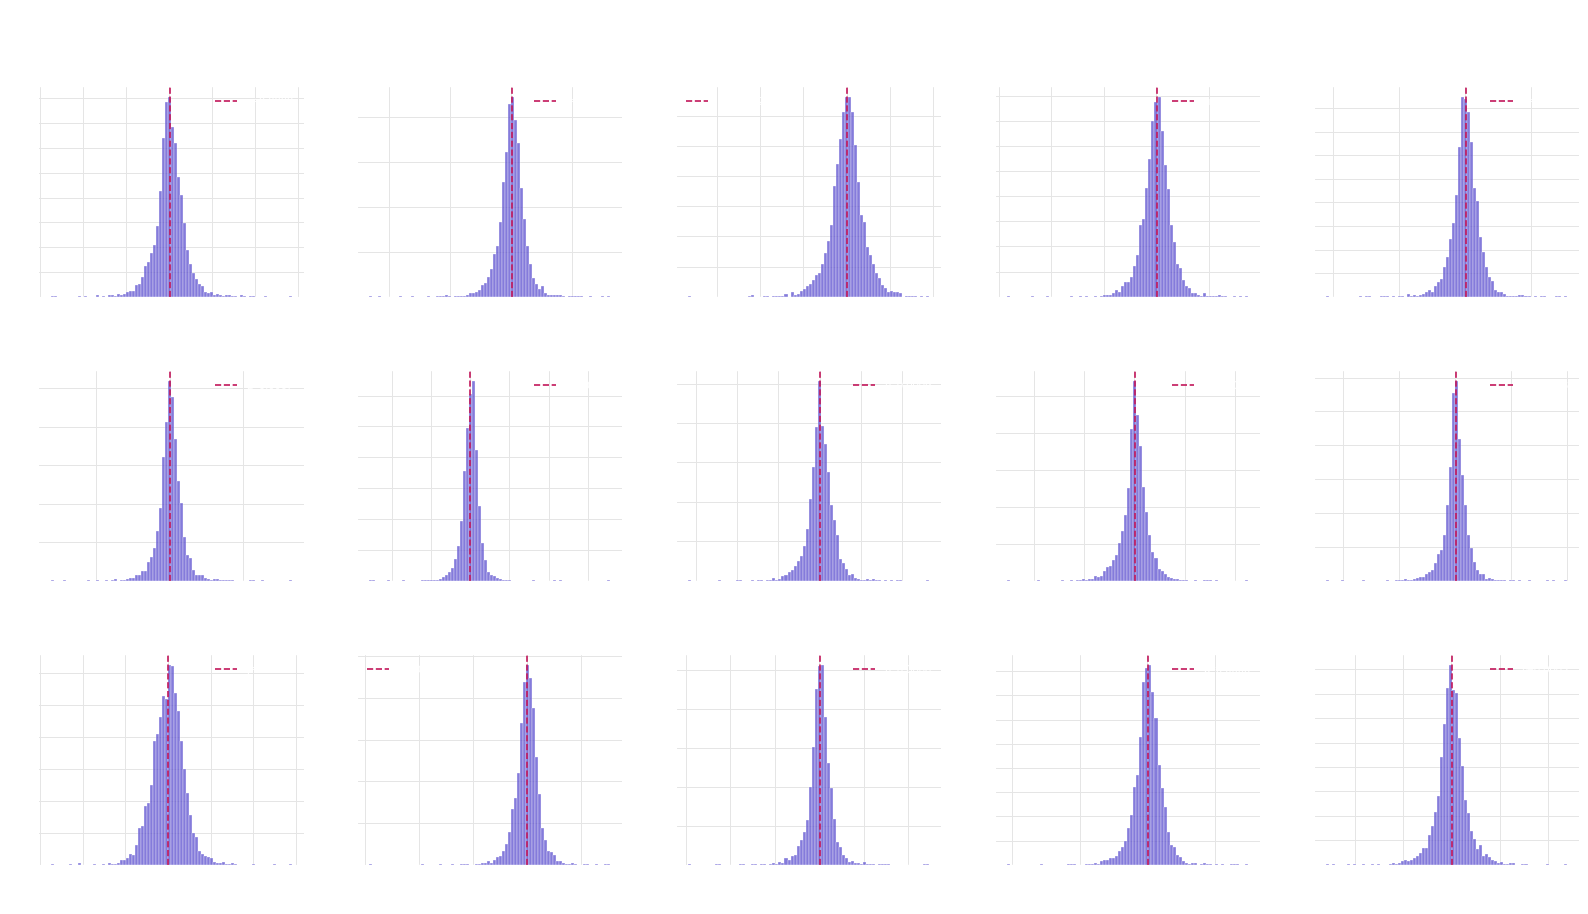

In [12]:
tickers = list(price.columns)
n = len(tickers)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    data = price[ticker].dropna()
    ax.hist(data, bins=80, color='#5b4fcf', alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(), color='#c2185b', linewidth=1.2, linestyle='--', label=f'μ={data.mean():.4f}')
    ax.set_title(ticker, fontweight='bold')
    ax.set_xlabel('log-return')
    ax.legend(fontsize=8, frameon=False)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Log-return distributions (all dates)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Log-return time series

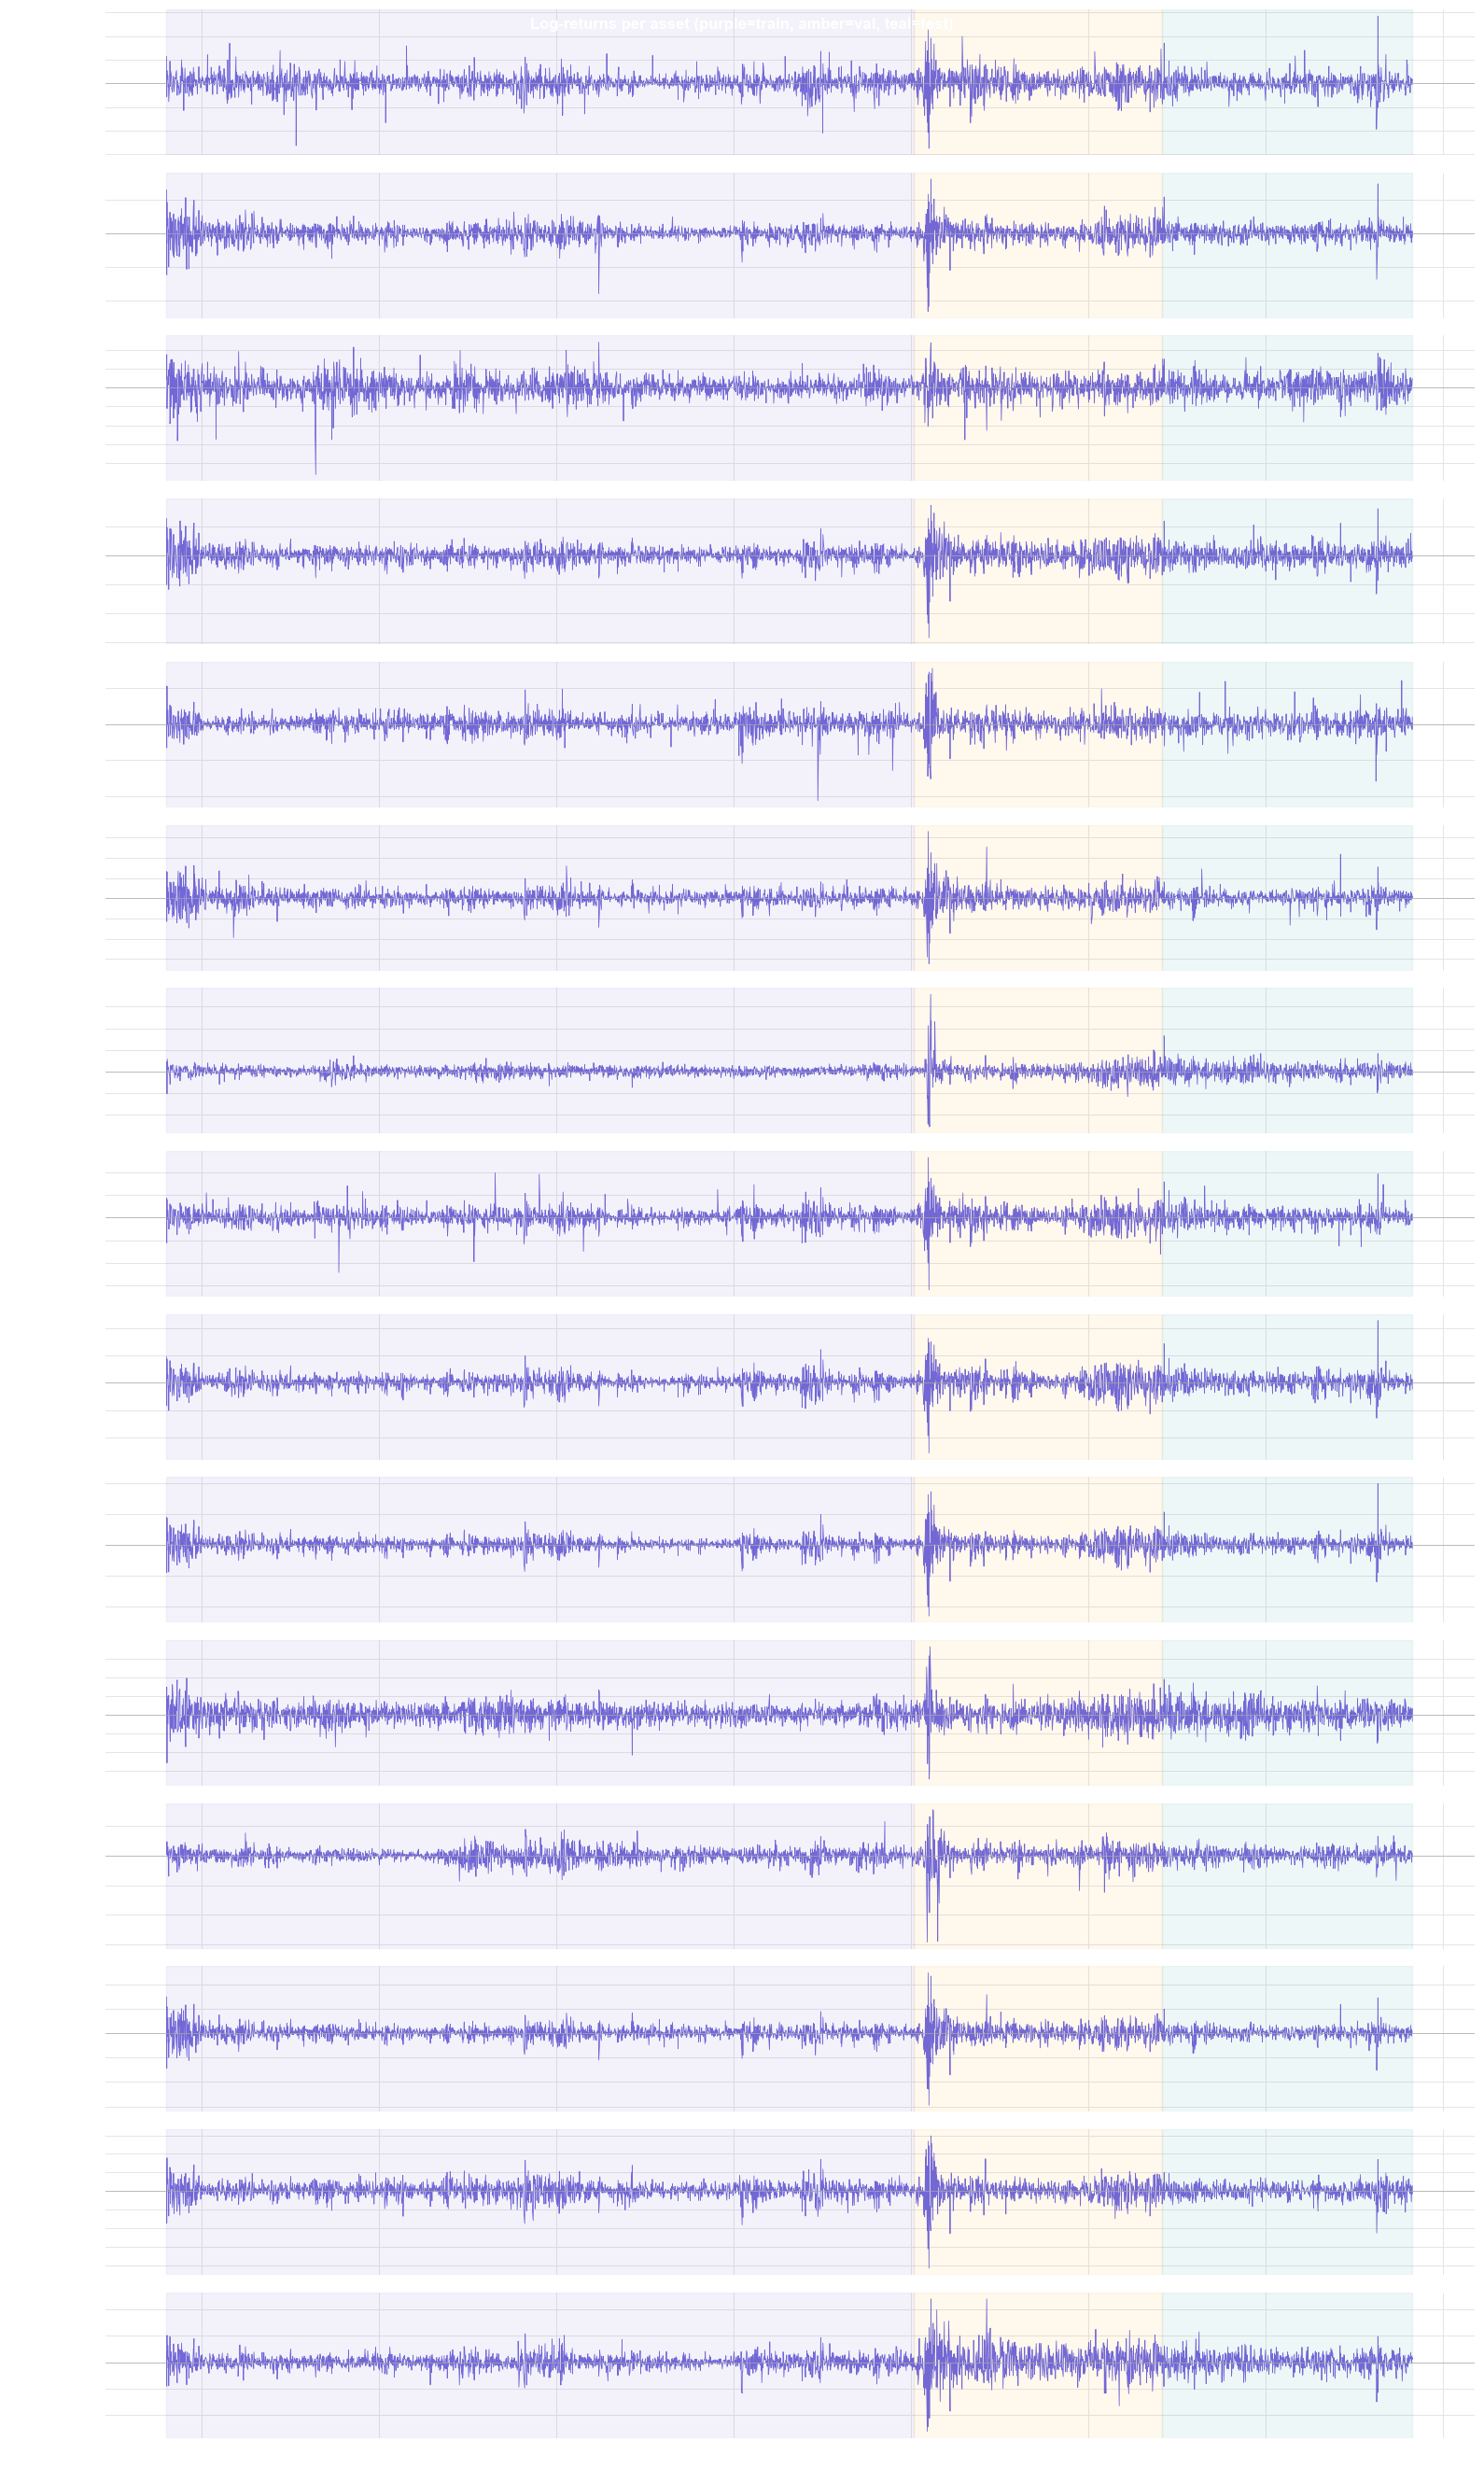

In [13]:
fig, axes = plt.subplots(n, 1, figsize=(16, n * 1.8), sharex=True)

for i, ticker in enumerate(tickers):
    ax = axes[i]
    series = price[ticker]
    ax.plot(series.index, series.values, linewidth=0.6, color='#5b4fcf', alpha=0.85)
    ax.axhline(0, color='#aaa', linewidth=0.5, linestyle='-')
    ax.set_ylabel(ticker, rotation=0, labelpad=38, fontsize=9, fontweight='bold', va='center')
    ax.tick_params(labelsize=7)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # shade train/val/test regions
    for name, df in splits.items():
        ax.axvspan(df.index[0], df.index[-1], alpha=0.07, color=colours[name])

axes[-1].set_xlabel('Date')
fig.suptitle('Log-returns per asset (purple=train, amber=val, teal=test)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Correlation matrix

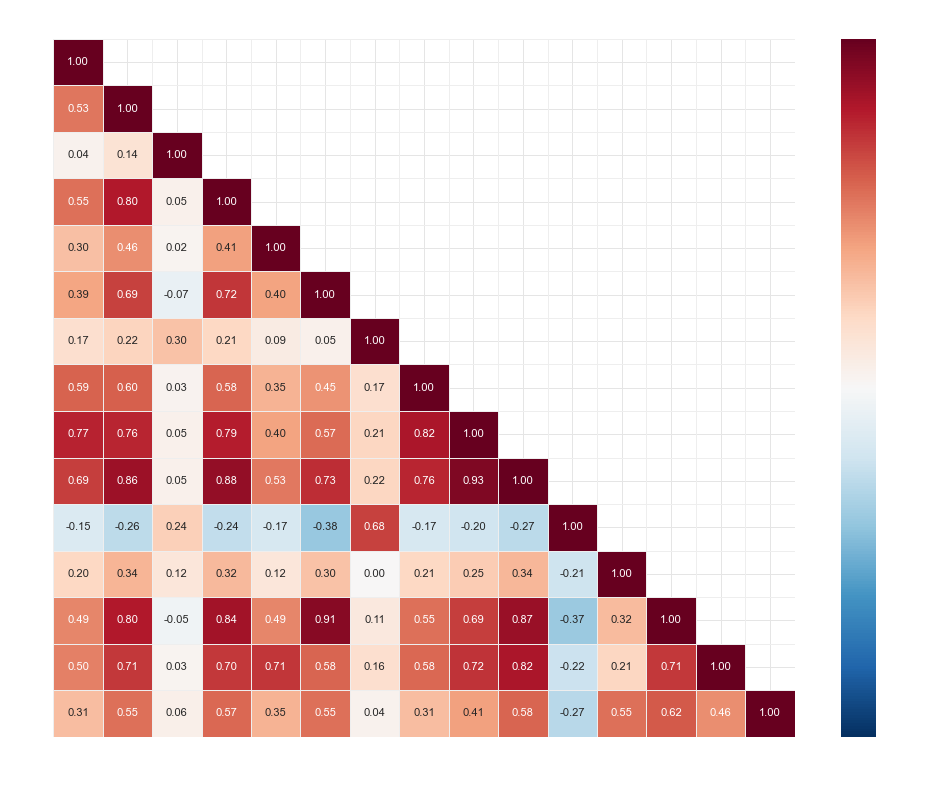

In [14]:
corr = price.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#eee',
    annot_kws={'size': 8},
    ax=ax,
)
ax.set_title('Pairwise log-return correlation', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## 9. Volume data — same structure

In [15]:
print('volume shape:', volume.shape)
volume.describe().T.round(4)

volume shape: (3536, 15)


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,3536.0,-0.0010,0.3121,-1.7725,-0.1958,-0.0207,0.1836,1.5628
EFA,3536.0,-0.0003,0.3476,-1.2765,-0.2241,-0.0109,0.2189,1.4437
GLD,3536.0,-0.0003,0.4436,-1.6429,-0.3070,-0.0220,0.2739,1.9309
IWM,3536.0,-0.0005,0.3991,-9.3051,-0.2088,-0.0139,0.2025,10.4254
JNJ,3536.0,-0.0004,0.3284,-1.5410,-0.1949,-0.0112,0.1790,2.2697
JPM,3536.0,-0.0008,0.3160,-1.5087,-0.1949,-0.0118,0.1870,1.8025
LQD,3536.0,0.0007,0.4620,-1.9403,-0.2824,-0.0076,0.2663,2.4879
MSFT,3536.0,-0.0005,0.3219,-1.6554,-0.1900,-0.0164,0.1831,1.9788
QQQ,3536.0,-0.0004,0.3294,-1.4996,-0.2153,-0.0045,0.2040,1.4666


In [16]:
volume.head(5)

Ticker,AAPL,EFA,GLD,IWM,JNJ,JPM,LQD,MSFT,QQQ,SPY,TLT,USO,XLF,XLV,XOM
Date,,,,,,,,,,,,,,,
2011-08-09,-0.055035,0.032246,0.259905,0.200161,0.112613,-0.309621,-0.189252,-0.061344,-0.055709,0.021922,0.041518,0.111971,-0.451613,-0.061790,0.048026
2011-08-10,-0.208711,-0.250029,-0.219015,-0.130826,-0.104452,0.061261,-0.511221,0.012208,0.061130,-0.080048,0.147524,-0.254549,0.491515,-0.058853,-0.256995
2011-08-11,-0.169087,-0.193412,0.107641,-0.403035,0.024940,-0.188000,0.384669,-0.343174,-0.358878,-0.305909,-0.201387,-0.111729,0.026618,-0.295629,0.052421
2011-08-12,-0.338365,-0.308418,-0.534933,-0.343173,0.233393,-0.456685,0.054506,-0.336342,-0.463434,-0.441736,-0.885366,-0.632938,-0.716686,-0.508716,-0.480434
2011-08-15,-0.138535,-0.227014,-0.495767,-0.406050,-0.072568,-0.235424,-0.040612,-0.136346,-0.207141,-0.192441,-0.438939,-0.093219,-0.175137,0.477027,-0.285908


---
## 10. What a single model input looks like — rolling window

The DDPG actor receives a **flattened rolling window** of shape `(window_size × n_assets,)`.  
Here we reconstruct exactly one sample as the model sees it, before any encoding transformation.

In [17]:
WINDOW_SIZE = 30  # matches GLOBAL_CONFIG['LOOKBACK_WINDOW']

# Take the first window from training data
window_df   = price_train.iloc[:WINDOW_SIZE]          # (30, 15)
window_flat = window_df.values.flatten()              # (450,)

print(f'Window shape (unflattened): {window_df.shape}  →  dates {window_df.index[0].date()} to {window_df.index[-1].date()}')
print(f'Flattened input to actor  : {window_flat.shape}')
print(f'Value range               : [{window_flat.min():.5f}, {window_flat.max():.5f}]')
print(f'Contains zeros (fillna)   : {(window_flat == 0).sum()}')

Window shape (unflattened): (30, 15)  →  dates 2011-08-09 to 2011-09-20
Flattened input to actor  : (450,)
Value range               : [-0.07200, 0.07446]
Contains zeros (fillna)   : 1


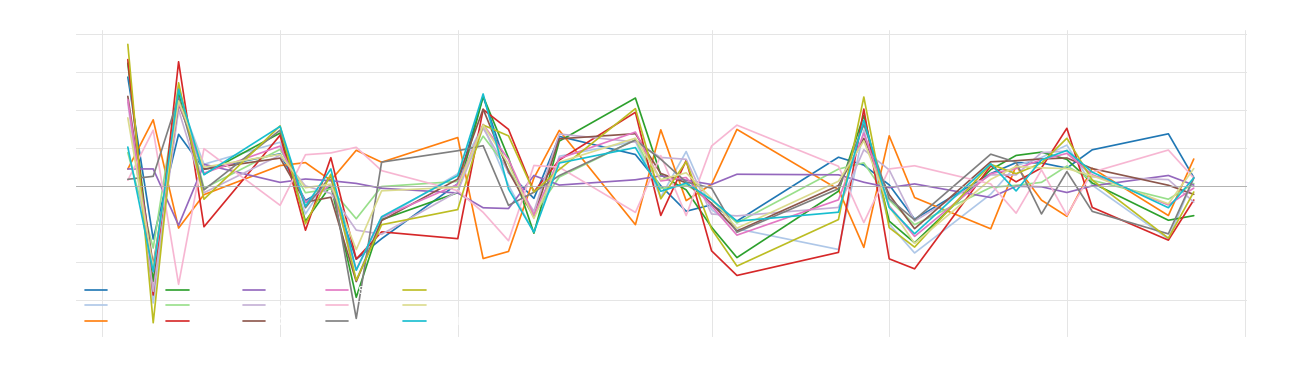

In [18]:
# Visualise the unflattened window — one line per asset
fig, ax = plt.subplots(figsize=(13, 4))
cmap = plt.get_cmap('tab20')

for i, ticker in enumerate(tickers):
    ax.plot(window_df.index, window_df[ticker], linewidth=1.2,
            color=cmap(i / len(tickers)), label=ticker)

ax.axhline(0, color='#aaa', linewidth=0.6)
ax.set_title(f'One input window — {WINDOW_SIZE} days × {len(tickers)} assets', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('log-return')
ax.legend(ncol=5, fontsize=8, frameon=False, loc='lower left')
plt.tight_layout()
plt.show()

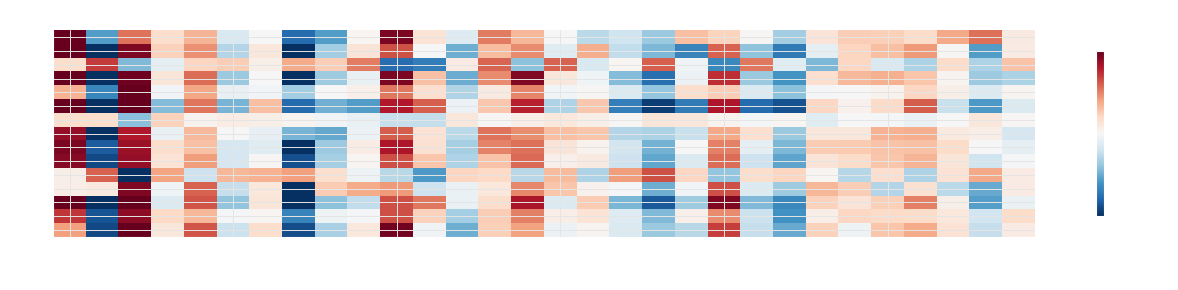

In [19]:
# Show what the flat vector looks like as an image (time × asset)
fig, ax = plt.subplots(figsize=(13, 3))
im = ax.imshow(
    window_df.values.T,           # (n_assets, window_size)
    aspect='auto',
    cmap='RdBu_r',
    vmin=-0.05, vmax=0.05,
)
ax.set_yticks(range(len(tickers)))
ax.set_yticklabels(tickers, fontsize=9)
ax.set_xlabel('Day within window (t=0 → oldest)')
ax.set_title('Heatmap of one input window', fontweight='bold')
plt.colorbar(im, ax=ax, label='log-return', shrink=0.8)
plt.tight_layout()
plt.show()

---
## 11. How many windows exist in each split

Each window consumes `WINDOW_SIZE` rows, so the number of usable samples per split is `len(split) - WINDOW_SIZE`.

In [20]:
for name, df in splits.items():
    n_windows = len(df) - WINDOW_SIZE
    print(f'{name:6s}: {len(df):5d} rows  →  {n_windows:5d} windows  ({n_windows * len(tickers) * WINDOW_SIZE:,} total values per batch pass)')

train :  2121 rows  →   2091 windows  (940,950 total values per batch pass)
val   :   707 rows  →    677 windows  (304,650 total values per batch pass)
test  :   708 rows  →    678 windows  (305,100 total values per batch pass)
